<a href="https://colab.research.google.com/github/Diwash17/6CS012-AI-And-ML/blob/main/worksheet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pillow

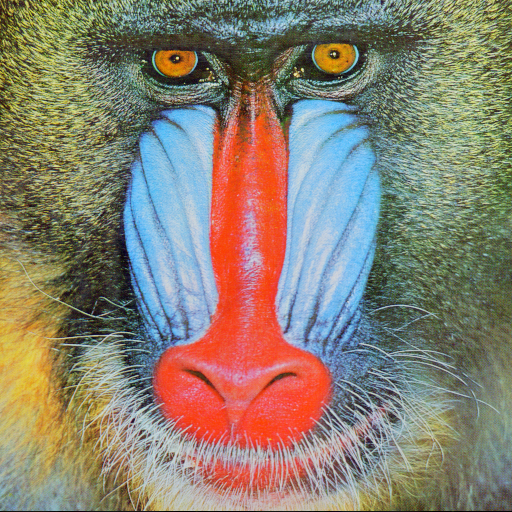

In [ ]:
from PIL import Image
image_path = "/content/drive/MyDrive/AI And ML 6CS012/week1/baboon.png"
image = Image.open(image_path)
display(image)


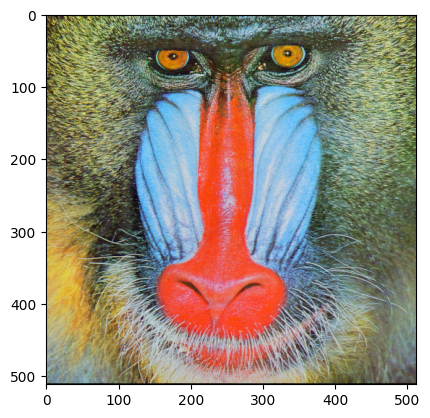

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(image)
plt.show()

In [ ]:
import numpy as np

In [ ]:
image_array = np.array(image)
display(image_array.shape)

(512, 512, 3)

array[row_start:row_end, col_start:col_end]

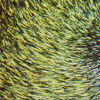

In [ ]:
top_left = image_array[0:100, 0:100]
top_left_image = Image.fromarray(top_left)
display(top_left_image)

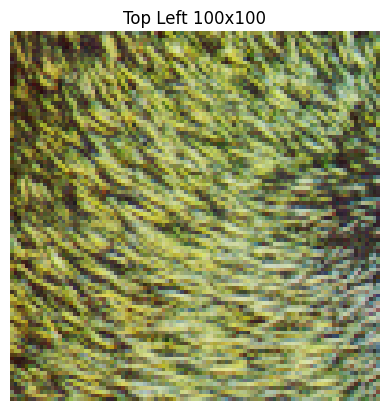

In [ ]:
plt.imshow(top_left)
plt.axis("off")
plt.title("Top Left 100x100")
plt.show()

(height, width, 3)

In [ ]:
img_path = "/content/drive/MyDrive/AI And ML 6CS012/week1/grayscale.gif"
grayscale_img = Image.open(img_path)

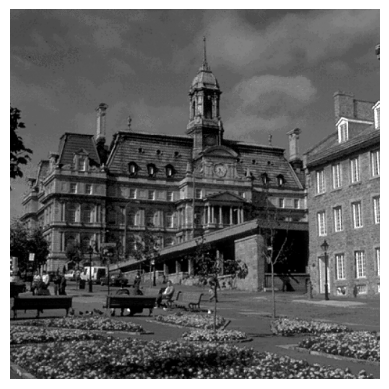

In [ ]:
plt.imshow(grayscale_img,cmap='gray')
plt.axis("off")
plt.show()

In [ ]:
img_array = np.array(grayscale_img)
h, w = img_array.shape[:2]
display(h,w)

512

512

In [ ]:
cropped = img_array[h//2 - 75 : h//2 + 75,
                    w//2 - 75 : w//2 + 75]

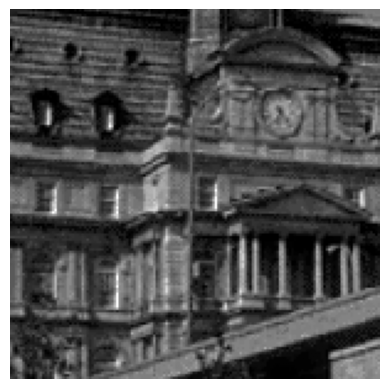

In [ ]:
plt.imshow(cropped,cmap= 'gray')
plt.axis("off")
plt.show()

In [ ]:
# Apply threshold: below 100 → 0, 100+ → 255
img_array[img_array < 100] = 0
img_array[img_array >= 100] = 255

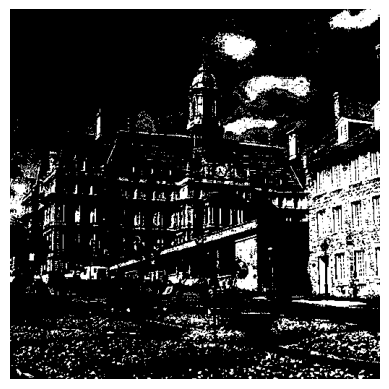

In [ ]:
plt.imshow(img_array, cmap='gray')
plt.axis("off")
plt.show()

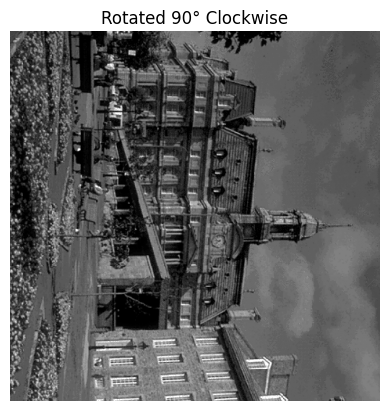

In [ ]:
rotated_img = grayscale_img.rotate(-90, expand=True)
plt.imshow(rotated_img, cmap='gray')
plt.axis("off")
plt.title("Rotated 90° Clockwise")
plt.show()

In [ ]:
rgb_img = grayscale_img.convert("RGB")

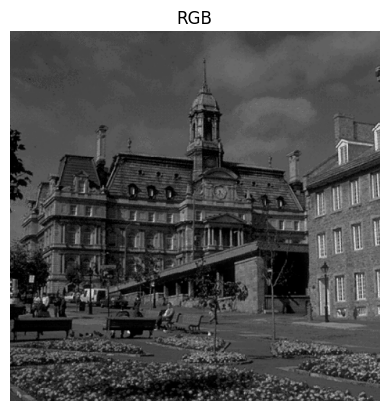

In [ ]:
plt.imshow(rgb_img)
plt.axis("off")
plt.title("RGB")
plt.show()

In [ ]:
print(rgb_img.mode)

RGB


In [ ]:
img = Image.open("/content/drive/MyDrive/AI And ML 6CS012/week1/cameraman.png")

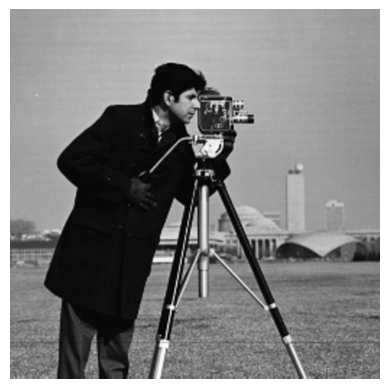

In [ ]:
plt.imshow(img, cmap ='gray')
plt.axis('off')
plt.show()

In [ ]:
image_array = np.array(img, dtype=float)
original_shape = img_array.shape
print("Original image shape:", original_shape)

Original image shape: (512, 512)


In [ ]:
X = image_array.copy()

In [ ]:
X_centered = X - np.mean(X, axis=0)
display(X_centered.shape)

(512, 512)

In [ ]:
cov_matrix = np.cov(X_centered.T)

In [ ]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

In [ ]:
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

In [ ]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

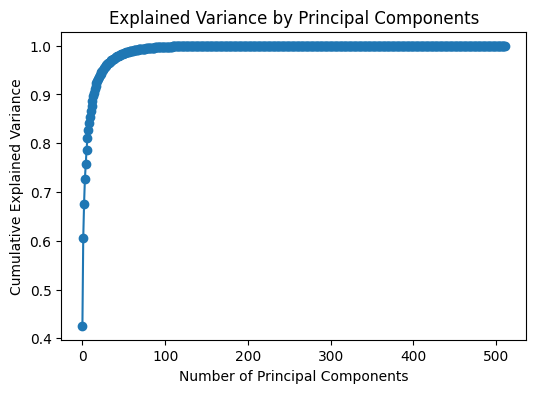

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Principal Components")
plt.show()

In [ ]:
# Reconstruction Function
def reconstruct_image(X, eigenvectors, k):
    top_eigenvectors = eigenvectors[:, :k]
    # Project onto top k components
    X_reduced = np.dot(X, top_eigenvectors)
    # Reconstruct original image
    X_reconstructed = np.dot(X_reduced, top_eigenvectors.T)
    # Add mean back
    X_reconstructed += np.mean(X, axis=0)
    return X_reconstructed

#  Experiment with different k (number of PCs)
k_values = [5, 20, 50, 100]  # choose based on cumulative variance

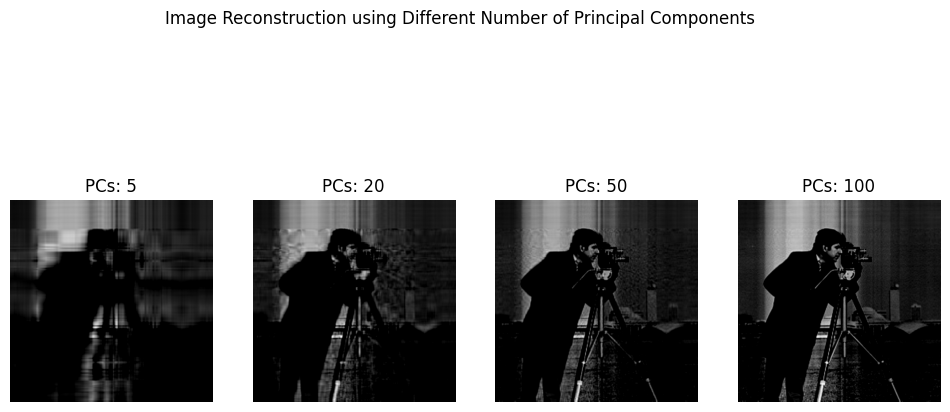

In [ ]:
plt.figure(figsize=(12,6))
for i, k in enumerate(k_values):
    reconstructed = reconstruct_image(X_centered, eigenvectors, k)
    reconstructed = np.clip(reconstructed, 0, 255)
    plt.subplot(1,4,i+1)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"PCs: {k}")
    plt.axis('off')
plt.suptitle("Image Reconstruction using Different Number of Principal Components")
plt.show()